In [12]:
%reset -f
from cProfile import label
from xmlrpc.client import Error

import numpy as np
import matplotlib.pyplot as plt
from __future__ import annotations

import pyvista as pv
pv.set_jupyter_backend('client')
import scipy.optimize as scp
import uproot
import matplotlib
from holoviews.plotting.bokeh.styles import font_size
from networkx import convert_node_labels_to_integers
from pandas.compat.numpy.function import validate_max
from vispy.gloo.gl import GL_UNSIGNED_SHORT_4_4_4_4

font = {'weight' : 'bold',
        'size'   : 15}

matplotlib.rc('font', **font)
### Opticks Nexus Analysis

import h5py
from pandas import read_hdf
import seaborn as sns
import scipy.special as misc
from scipy.special import loggamma
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import fireducks.pandas as pd
import os


In [2]:
### This is used for debugging purposes
def GetInfo(filePath,FileLimit=-1,isCombined=True,EventLimit=-1,SkipKeys=None,SkipSubKeys=None):
    All={}
    subVal={}
    subsubVal={}
    if(filePath.endswith("h5")):
        f=h5py.File(filePath,"r")
        
        for folder in f:
            subVal={}
            for table in f[folder]:
                subsubVal={}
                if(SkipKeys!=None and table in SkipKeys ):
                    continue
                    
                for field in f[folder][table].dtype.fields.keys():
                    if(field in SkipSubKeys):
                        continue 
                    subsubVal[field]=f[folder][table][field]
                if(subsubVal):    
                    subVal[table]=subsubVal
            All[folder]=subVal
        f.close()
    else:
        Files=ListofFiles(filePath)
        Counter=0
        Combined={}
        SingleFile={}
        for file in Files:
            f=h5py.File(file,"r")
            print(file)
            if(not isCombined):
                SingleFile={}
            for folder in f:
                subVal={}
                for table in f[folder]:
                    subsubVal={}
                    if(SkipKeys!=None and table in SkipKeys ):
                        continue
                    for field in f[folder][table].dtype.fields.keys():
                        #if no value then ignore it
                        
                        if(field in SkipSubKeys):
                            continue
                        subsubVal[field]=np.array(f[folder][table][field])
    
                        if(subsubVal[field].size == 0):
                            continue
                        if(Combined):
                            MaxEventID=0
                            if(field=="event_id" and Counter>0):
                                #print(f"{table}/{field}")
                                MaxEventID=np.max(Combined[table][field])+1
                                #print(Combined[table][field])
                                subsubVal[field]=MaxEventID+subsubVal[field]
                                #print(MaxEventID)
                                #print(subsubVal[field])
                            Combined[table][field]=np.hstack((Combined[table][field],subsubVal[field]))
                    if(subsubVal):        
                        subVal[table]=subsubVal
                if(not isCombined and (subVal)):    
                    SingleFile[folder]=subVal
                else:
                    if(Counter==0 and (subVal)):
                        print("Setting Combined Value")
                        Combined=subVal
            f.close()
            if(not isCombined):
                All[Counter]=SingleFile
            if(FileLimit==Counter):
                break   
            Counter+=1
        if(isCombined):
            All=Combined
    return All


import h5py
from concurrent.futures import ThreadPoolExecutor

def process_folder(folder, data):
    subVal = {}
    for table in data[folder]:
        subsubVal = {field: data[folder][table][field] for field in data[folder][table].dtype.fields.keys()}
        subVal[table] = subsubVal
    return folder, subVal

def GetInfoM(filePath):
    All = {}
    with h5py.File(filePath, "r") as f:
        data = {folder: {table: f[folder][table][:] for table in f[folder]} for folder in f}
        with ThreadPoolExecutor(max_workers=20) as executor:
            results = list(executor.map(lambda folder: process_folder(folder, data), data.keys()))
        All = dict(results)
    return All

### Get all
import os
folder="NEXTCRAB_Debug"
tmpPath="/home/argon/Projects/Ilker/OpticksRay/"
files=os.listdir(f"{tmpPath}{folder}/nexus/ALL0/")

Hits={}
Steps={}
Records={}
Photons={}
GenStep={}
All=sorted(files)[:-2]
print (f" All the event files {All}")
Count=0
for i in All:
    record=np.load(f"{tmpPath}/{folder}/nexus/ALL0/{i}/record.npy")
    photon=np.load(f"{tmpPath}/{folder}/nexus/ALL0/{i}/photon.npy")
    hit=np.load(f"{tmpPath}/{folder}/nexus/ALL0/{i}/hit.npy")
    #seq=np.load(f"{tmpPath{older}/nexus/ALL0/{i}/seq.npy")
    gen=np.load(f"{tmpPath}/{folder}/nexus/ALL0/{i}/genstep.npy")
    Hits[Count]=hit
    Records[Count]=record
    Photons[Count]=photon
    GenStep[Count]=gen
    Steps[Count]=record[:,0,0,:3] ## Position and time of first 5 steps
    Count=Count+1



 All the event files ['A000']


In [3]:
#Conversions
boundary_  = lambda p:p.view(np.uint32) >> 16    
flag_      = lambda p:p.view(np.uint32) & 0xffff

identity_ = lambda p:p.view(np.uint32)[3,1]   
primIdx_   = lambda p:identity_(p) >> 16  
instanceId_  = lambda p:identity_(p) & 0xffff  

idx_      = lambda p:p.view(np.uint32)[3,2] & 0x7fffffff
orient_   = lambda p:p.view(np.uint32)[3,2] >> 31

flagmask_ = lambda p:p.view(np.uint32)


class PhotonFlag:
    CERENKOV = 1 << 0
    SCINTILLATION = 1 << 1
    MISS = 1 << 2
    BULK_ABSORB = 1 << 3
    BULK_REEMIT = 1 << 4
    BULK_SCATTER = 1 << 5
    SURFACE_DETECT = 1 << 6
    SURFACE_ABSORB = 1 << 7
    SURFACE_DREFLECT = 1 << 8
    SURFACE_SREFLECT = 1 << 9
    BOUNDARY_REFLECT = 1 << 10
    BOUNDARY_TRANSMIT = 1 << 11
    TORCH = 1 << 12
    NAN_ABORT = 1 << 13
    EFFICIENCY_CULL = 1 << 14
    EFFICIENCY_COLLECT = 1 << 15
    __NATURAL = 1 << 16
    __MACHINERY = 1 << 17
    __EMITSOURCE = 1 << 18
    PRIMARYSOURCE = 1 << 19
    GENSTEPSOURCE = 1 << 20
    DEFER_FSTRACKINFO = 1 << 21
    
class PhotonFlagNames:
    ZERO = "."
    CERENKOV = "CERENKOV"
    SCINTILLATION = "SCINTILLATION"
    TORCH = "TORCH"
    MISS = "MISS"
    BULK_ABSORB = "BULK_ABSORB"
    BULK_REEMIT = "BULK_REEMIT"
    BULK_SCATTER = "BULK_SCATTER"
    SURFACE_DETECT = "SURFACE_DETECT"
    SURFACE_ABSORB = "SURFACE_ABSORB"
    SURFACE_DREFLECT = "SURFACE_DREFLECT"
    SURFACE_SREFLECT = "SURFACE_SREFLECT"
    BOUNDARY_REFLECT = "BOUNDARY_REFLECT"
    BOUNDARY_TRANSMIT = "BOUNDARY_TRANSMIT"
    NAN_ABORT = "NAN_ABORT"
    EFFICIENCY_CULL = "EFFICIENCY_CULL"
    EFFICIENCY_COLLECT = "EFFICIENCY_COLLECT"
    BAD_FLAG = "BAD_FLAG"
    DEFER_FSTRACKINFO = "DEFER_FSTRACKINFO"

def GetFlag(flag):
    particle_event_types = {
        0: PhotonFlagNames.ZERO,
        PhotonFlag.CERENKOV: PhotonFlagNames.CERENKOV,
        PhotonFlag.SCINTILLATION: PhotonFlagNames.SCINTILLATION,
        PhotonFlag.MISS: PhotonFlagNames.MISS,
        PhotonFlag.BULK_ABSORB: PhotonFlagNames.BULK_ABSORB,
        PhotonFlag.BULK_REEMIT: PhotonFlagNames.BULK_REEMIT,
        PhotonFlag.BULK_SCATTER: PhotonFlagNames.BULK_SCATTER,
        PhotonFlag.SURFACE_DETECT: PhotonFlagNames.SURFACE_DETECT,
        PhotonFlag.SURFACE_ABSORB: PhotonFlagNames.SURFACE_ABSORB,
        PhotonFlag.SURFACE_DREFLECT: PhotonFlagNames.SURFACE_DREFLECT,
        PhotonFlag.SURFACE_SREFLECT: PhotonFlagNames.SURFACE_SREFLECT,
        PhotonFlag.BOUNDARY_REFLECT: PhotonFlagNames.BOUNDARY_REFLECT,
        PhotonFlag.BOUNDARY_TRANSMIT: PhotonFlagNames.BOUNDARY_TRANSMIT,
        PhotonFlag.TORCH: PhotonFlagNames.TORCH,
        PhotonFlag.NAN_ABORT: PhotonFlagNames.NAN_ABORT,
        PhotonFlag.EFFICIENCY_COLLECT: PhotonFlagNames.EFFICIENCY_COLLECT,
        PhotonFlag.EFFICIENCY_CULL: PhotonFlagNames.EFFICIENCY_CULL,
        PhotonFlag.DEFER_FSTRACKINFO: PhotonFlagNames.DEFER_FSTRACKINFO
    }
    if(flag in particle_event_types):
        return particle_event_types[flag]
    else:
        return particle_event_types.get(flag, PhotonFlagNames.BAD_FLAG)
def GetPhotonsPositionsFromRecord(Rec,Event,Mask):
    xR=Rec[Event][:,:,0,0].ravel()[Mask]
    yR=Rec[Event][:,:,0,1].ravel()[Mask]
    zR=Rec[Event][:,:,0,2].ravel()[Mask]

    return np.stack((xR.reshape(-1),yR.reshape(-1),zR.reshape(-1)),axis=1)

# Get S1 and S2 Photons
def GetS1andS2PhotonsFromRecord(Rec,Event,Mask,Time):
    ## Coordinates
    tR=Rec[Event][:,:,0,3].ravel()[Mask]
    # Get Masking
    S1Mask=tR<=Time

    S1_xR=Rec[Event][:,:,0,0].ravel()[Mask][S1Mask]
    S1_yR=Rec[Event][:,:,0,1].ravel()[Mask][S1Mask]
    S1_zR=Rec[Event][:,:,0,2].ravel()[Mask][S1Mask]
    S1_tR=Rec[Event][:,:,0,3].ravel()[Mask][S1Mask]

    S2Mask=tR>Time
    S2_xR=Rec[Event][:,:,0,0].ravel()[Mask][S2Mask]
    S2_yR=Rec[Event][:,:,0,1].ravel()[Mask][S2Mask]
    S2_zR=Rec[Event][:,:,0,2].ravel()[Mask][S2Mask]
    S2_tR=Rec[Event][:,:,0,3].ravel()[Mask][S2Mask]
    return list(zip(S1_xR, S1_yR, S1_zR)),list(zip(S2_xR, S2_yR, S2_zR)),[[S1_xR,S1_yR,S1_zR,S1_tR],[S2_xR,S2_yR,S2_zR,S2_tR]]


    

In [4]:
OpticksFilePath="/home/argon/Projects/Ilker/NewNexus/" 
OFile=OpticksFilePath + "OpticksPTestv2.h5"
#G4Folder=G4FilePath+"Reflections/"
#vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Oct_13_2024/OpticksTest_With_ReflectionOff_2k_All.h5")

result=GetInfo(OFile,SkipKeys=["sns_positions","sns_response","hits","configuration","Timing"],SkipSubKeys=["hit_id","polx","poly","polz","momx","momy","momz","name"])


In [5]:
print(result["DEBUG"].keys())
OpticksSteps=result["DEBUG"]["opticks_photon_info"]
G4Steps=result["DEBUG"]["steps"]
Particles=result["MC"]["particles"]
Opticks=result["DEBUG"]["opticks_photon_info"]

dict_keys(['opticks_photon_info', 'steps'])


In [6]:
### Steps
AlphaMask=G4Steps["particle_name"]==b"alpha"
AlphasInitX=G4Steps["initial_x"][AlphaMask]
AlphasInitY=G4Steps["initial_y"][AlphaMask]
AlphasInitZ=G4Steps["initial_z"][AlphaMask]
AlphasFinalX=G4Steps["final_x"][AlphaMask]
AlphasFinalY=G4Steps["final_y"][AlphaMask]
AlphasFinalZ=G4Steps["final_z"][AlphaMask]
AlphasT=G4Steps["time"][AlphaMask]


### Lets Seperate the S1 and S2

PhotonMask=Particles["particle_name"]==b"opticalphoton"
PhotonFinalT=Particles["final_t"][PhotonMask]
S1Mask=PhotonFinalT<=1500
S2Mask=PhotonFinalT>1500

S1PhotonInitX=Particles["initial_x"][PhotonMask][S1Mask]
S1PhotonInitY=Particles["initial_y"][PhotonMask][S1Mask]
S1PhotonInitZ=Particles["initial_z"][PhotonMask][S1Mask]
S1PhotonInitT=Particles["initial_t"][PhotonMask][S1Mask]
S1PhotonFinalX=Particles["final_x"][PhotonMask][S1Mask]
S1PhotonFinalY=Particles["final_y"][PhotonMask][S1Mask]
S1PhotonFinalZ=Particles["final_z"][PhotonMask][S1Mask]
S1PhotonFinalT=Particles["final_t"][PhotonMask][S1Mask]

S2PhotonInitX=Particles["initial_x"][PhotonMask][S2Mask]
S2PhotonInitY=Particles["initial_y"][PhotonMask][S2Mask]
S2PhotonInitZ=Particles["initial_z"][PhotonMask][S2Mask]
S2PhotonInitT=Particles["initial_t"][PhotonMask][S2Mask]
S2PhotonFinalX=Particles["final_x"][PhotonMask][S2Mask]
S2PhotonFinalY=Particles["final_y"][PhotonMask][S2Mask]
S2PhotonFinalZ=Particles["final_z"][PhotonMask][S2Mask]
S2PhotonFinalT=Particles["final_t"][PhotonMask][S2Mask]


In [7]:
Particles.keys()

dict_keys(['event_id', 'particle_id', 'particle_name', 'primary', 'mother_id', 'initial_x', 'initial_y', 'initial_z', 'initial_t', 'final_x', 'final_y', 'final_z', 'final_t', 'initial_volume', 'final_volume', 'initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z', 'final_momentum_x', 'final_momentum_y', 'final_momentum_z', 'kin_energy', 'length', 'creator_proc', 'final_proc'])

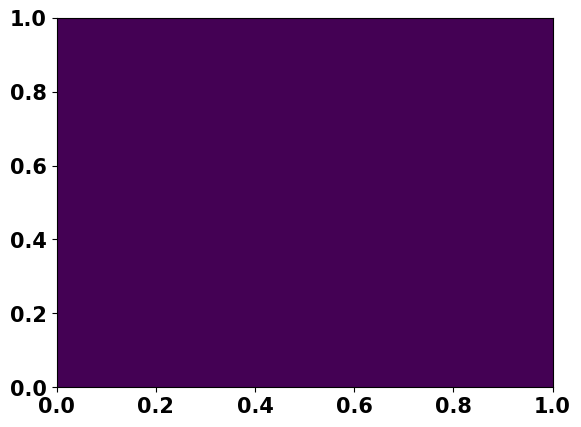

In [8]:
_=plt.hist2d(S1PhotonInitX,S1PhotonInitY,bins=300)


In [9]:
### Opticks Steps
Mask=(Opticks["x"]>100) | (Opticks["x"]<-100)
OpticksPInitX=Opticks["x"][Mask]
OpticksPInitY=Opticks["y"][Mask]
OpticksPInitZ=Opticks["z"][Mask]

In [10]:
OpticksPInitX

array([166.47307], dtype=float32)

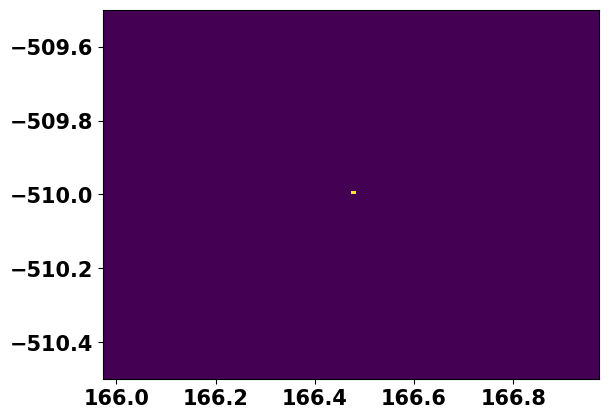

In [11]:
_=plt.hist2d(OpticksPInitX,OpticksPInitZ,bins=100)


In [13]:
Opticks

{'event_id': array([0, 0, 0, ..., 0, 0, 0]),
 'photon_id': array([      0,       1,       2, ..., 1962773, 1962774, 1962775],
       dtype=int32),
 'x': array([-75.48324  , -71.86428  ,  -2.6033049, ...,  -8.768411 ,
         58.38683  , -22.586239 ], dtype=float32),
 'y': array([ 32.035625,  20.062794,  81.958664, ...,  39.15617 ,  57.575848,
        -78.82805 ], dtype=float32),
 'z': array([-144.43738, -215.9    ,   84.91678, ..., -215.9    ,   98.76872,
        -157.59344], dtype=float32),
 'time': array([114420.88 , 114421.03 , 114421.305, ..., 113174.67 , 113175.02 ,
        113174.625], dtype=float32),
 'flag': array([b'SA', b'SA', b'SA', ..., b'SA', b'SA', b'SA'], dtype='|S100'),
 'wavelength': array([177.93802, 174.01329, 162.9202 , ..., 179.28873, 167.85689,
        169.33472], dtype=float32),
 'boundary': array([5, 4, 5, ..., 4, 5, 5], dtype=uint32),
 'identity': array([0, 0, 0, ..., 0, 0, 0], dtype=uint32)}

In [14]:
# Define line segment
Event=0
Flags=Records[Event][:,:,3,0]
GetFlagVector=np.vectorize(GetFlag)
FLg=GetFlagVector(flag_(Flags)).ravel()
S1start=list(zip(S1PhotonInitX, S1PhotonInitY, S1PhotonInitZ))

S1stop = list(zip(S1PhotonFinalX, S1PhotonFinalY, S1PhotonFinalZ))
# Define line segment
S2start=list(zip(S2PhotonInitX, S2PhotonInitY, S2PhotonInitZ))

S2stop = list(zip(S2PhotonFinalX, S2PhotonFinalY, S2PhotonFinalZ))
#Ostop = list(zip(S2PhotonFinalX, S2PhotonFinalY, S2PhotonFinalZ))

ScintilationPhotonsMask=FLg== (PhotonFlagNames.SCINTILLATION)
FinalScintilationPhotonsMask=FLg!= (PhotonFlagNames.SCINTILLATION)

S1andS2_Initial=GetS1andS2PhotonsFromRecord(Records,Event,ScintilationPhotonsMask,1500)
S1andS2_Final=GetS1andS2PhotonsFromRecord(Records,Event,FinalScintilationPhotonsMask,1500)

In [15]:




# Create geometry to represent ray trace
# Render the result
p = pv.Plotter()
for i in range(0,1000):
    #p.add_mesh(pv.Line(S1start[i], S1stop[i]), color="green", line_width=2,label=f"S1 G4 Photon_{i}")
    #p.add_mesh(pv.Line(S1andS2_Initial[0][i], S1andS2_Final[0][i]), color="red", line_width=2,label=f"S2 Opticks Photon_{i}")
    ## S2 Photons
    p.add_mesh(pv.Line(S2start[i], S2stop[i]), color="green", line_width=1,opacity=0.3,label=f"S2 G4 Photon_{i}")
    p.add_mesh(pv.Line(S1andS2_Initial[1][i], S1andS2_Final[1][i]), color="red",opacity=0.3, line_width=1,label=f"S2 Opticks Photon_{i}")

#p.add_mesh(ray, color="green", line_width=5, label="G4 Photon")
p.add_legend()
p.show()

Widget(value='<iframe src="http://localhost:32877/index.html?ui=P_0x7fefc53fbcd0_0&reconnect=auto" class="pyvi…

In [16]:
# Create geometry to represent ray trace
# Render the result
p = pv.Plotter()
for i in range(0,1000):
    p.add_mesh(pv.Line(S1start[i], S1stop[i]), color="green", line_width=2,label=f"S1 G4 Photon_{i}",opacity=0.3)
    p.add_mesh(pv.Line(S1andS2_Initial[0][i], S1andS2_Final[0][i]), color="red", line_width=2,label=f"S1 Opticks Photon_{i}",opacity=0.3)

#p.add_mesh(ray, color="green", line_width=5, label="G4 Photon")
p.add_legend()
p.show()

IndexError: list index out of range

In [ ]:
Event=0
Flags=Records[Event][:,:,3,0]
GetFlagVector=np.vectorize(GetFlag)
FLg=GetFlagVector(flag_(Flags)).ravel()

S1start_points=np.stack((S1PhotonInitX.reshape(-1),S1PhotonInitY.reshape(-1),S1PhotonInitZ.reshape(-1)),axis=1)
S1stop_points=np.stack((S1PhotonFinalX.reshape(-1),S1PhotonFinalY.reshape(-1),S1PhotonFinalZ.reshape(-1)),axis=1)

S2start_points=np.stack((S2PhotonInitX.reshape(-1),S2PhotonInitY.reshape(-1),S2PhotonInitZ.reshape(-1)),axis=1)
S2stop_points=np.stack((S2PhotonFinalX.reshape(-1),S2PhotonFinalY.reshape(-1),S2PhotonFinalZ.reshape(-1)),axis=1)
#Ostop = list(zip(S2PhotonFinalX, S2PhotonFinalY, S2PhotonFinalZ))

ScintilationPhotonsMask=FLg== (PhotonFlagNames.SCINTILLATION)
FinalScintilationPhotonsMask=FLg!= (PhotonFlagNames.SCINTILLATION)

S1andS2_Initial=GetS1andS2PhotonsFromRecord(Records,Event,ScintilationPhotonsMask,1000)[2]
S1andS2_Final=GetS1andS2PhotonsFromRecord(Records,Event,FinalScintilationPhotonsMask,1000)[2]
S1Opticks_start_points=np.stack((S1andS2_Initial[0][0].reshape(-1),S1andS2_Initial[0][1].reshape(-1),S1andS2_Initial[0][2].reshape(-1)),axis=1)

S2Opticks_start_points=np.stack((S1andS2_Initial[1][0].reshape(-1),S1andS2_Initial[1][1].reshape(-1),S1andS2_Initial[1][2].reshape(-1)),axis=1)

In [ ]:
pl=pv.Plotter()
#pl.add_mesh(TransitPhotons,color="red",opacity=0.9,label="Photons Pass Through")
pl.add_mesh(S2start_points,color="green",opacity=1,label="S2_G4")
pl.add_mesh(S2Opticks_start_points,color="red",opacity=0.5,label="S2_G4")

    
pl.add_legend()     
pl.show_grid()

pl.show()

In [ ]:
pl=pv.Plotter()
#pl.add_mesh(TransitPhotons,color="red",opacity=0.9,label="Photons Pass Through")
pl.add_mesh(S1start_points,color="green",opacity=1,label="S2_G4")
pl.add_mesh(S1Opticks_start_points,color="red",opacity=0.5,label="S2_G4")

    
pl.add_legend()     
pl.show_grid()

pl.show()

In [ ]:
plt.figure(figsize=(12,12),dpi=300)
#plt.title("S2 Photons Initial position")
_=plt.hist(S2PhotonInitZ,bins=200,color="green",alpha=0.3,edgecolor="red",histtype="step",fill=True,label="G4")
_=plt.hist(S1andS2_Initial[1][2],bins=200,color="red",alpha=0.3,edgecolor="red",histtype="step",fill=True,label="Opticks")
plt.xlabel("Z(mm)",fontsize=25)
plt.ylabel("Photons",fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)    
plt.legend(fontsize=20)

In [ ]:
plt.figure(figsize=(12,12),dpi=300)
#plt.title("S1 Photons Z component ",fontsize=55)

_=plt.hist(S1PhotonInitZ,bins=200,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True,label="G4")
_=plt.hist(S1andS2_Initial[0][2],bins=200,color="red",alpha=0.3,edgecolor="red",histtype="step",fill=True,label="Opticks")
plt.xlabel("Z(mm)",fontsize=25)
plt.ylabel("Photons",fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)    
plt.legend(fontsize=20)

In [ ]:
plt.figure(figsize=(12,12),dpi=300)
#plt.title("S1 Photons Initial position")

_=plt.hist(S1PhotonInitX,bins=200,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True,label="G4")
_=plt.hist(S1andS2_Initial[0][0],bins=200,color="red",alpha=0.3,edgecolor="red",histtype="step",fill=True,label="Opticks")
plt.xlabel("x(mm)",fontsize=25)
plt.ylabel("Photons",fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)    
plt.legend(fontsize=20)

In [ ]:
plt.figure(figsize=(12,12),dpi=300)
#plt.title("S1 Photons Initial position")

_=plt.hist(S1PhotonInitY,bins=200,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True,label="G4")
_=plt.hist(S1andS2_Initial[0][1],bins=200,color="red",alpha=0.3,edgecolor="red",histtype="step",fill=True,label="Opticks")
plt.xlabel("y(mm)",fontsize=25)
plt.ylabel("Photons",fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)    
plt.legend(fontsize=20)

In [ ]:
## Y(mm)
plt.figure(figsize=(12,12),dpi=300)
#plt.title("S2 Photons Initial position")
_=plt.hist(S2PhotonInitY,bins=200,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True,label="G4")
_=plt.hist(S1andS2_Initial[1][1],bins=200,color="red",alpha=0.3,edgecolor="red",histtype="step",fill=True,label="Opticks")
plt.xlabel("Y(mm)",fontsize=25)
plt.ylabel("Photons",fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)    

plt.legend(fontsize=25)

In [ ]:
## x mm (S2)
plt.figure(figsize=(12,12),dpi=300)
#plt.title("S2 Photons Initial position")
_=plt.hist(S2PhotonInitX,bins=200,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True,label="G4")
_=plt.hist(S1andS2_Initial[1][0],bins=200,color="red", alpha=0.3,edgecolor="red",histtype="step",fill=True,label="Opticks")
plt.xlabel("x(mm)",fontsize=25)
plt.ylabel("Photons",fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)    

plt.legend(fontsize=25)

Traceback (most recent call last):
  File "/home/argon/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/argon/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/argon/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/argon/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/home/argon/anaconda3/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.start()
  File "/home/argon/anaconda3/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/home/argon/anaconda3/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run_once()
  File "/home/argon/anaconda3/lib/python3.10/asyncio/base_event